In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import time
import seaborn as sns
from sklearn.model_selection import train_test_split

# Подготовка данных

Чтение csv

In [46]:
df = pd.read_csv('iris.csv', sep=',')
df

,Sepal.L,Sepal.W,Petal.L,Petal.W,Kind
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


Удаление лишних столбцов

In [47]:
df['type'] = df['Kind'].map({'Iris-setosa': 1, 'Iris-versicolor': -1, 'Iris-virginica': -1})
df = df.drop('Kind', axis=1)
df = df.drop('Petal.L', axis=1)
df = df.drop('Petal.W', axis=1)
df

,Sepal.L,Sepal.W,type
0,5.1,3.5,1
1,4.9,3.0,1
2,4.7,3.2,1
3,4.6,3.1,1
4,5.0,3.6,1
...,...,...,...
145,6.7,3.0,-1
146,6.3,2.5,-1
147,6.5,3.0,-1
148,6.2,3.4,-1


Разделение выборки на тестовую и обучающую

In [48]:
X = df.drop('type', axis=1)
y = df['type']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=0)
X_train.reset_index(drop=True)
y_train.reset_index(drop=True)
X_test.reset_index(drop=True)
y_test.reset_index(drop=True)
len(X_train), len(X_test), len(y_train), len(y_test)

(100, 50, 100, 50)

# Создание модели SVM

In [49]:
class SVM:
    def __init__(self, learning_rate=0.01, num_epochs=1000):
        self.learning_rate = learning_rate
        self.num_epochs = num_epochs
        self.weights = None
        self.bias = None

    def fit(self, X_def, y, line = True):
        X = np.array([])
        if line:
            X = X_def
        else:
            for x in X_def:
                X = np.append(X, [x[0], x[1], x[0] * x[1], x[0] ** 2, x[1] ** 2])
            X = X.reshape((X_def.shape[0],5))

        num_samples, num_features = X.shape
        self.weights = np.zeros(num_features)
        self.bias = 0

        for epoch in range(self.num_epochs):
            for idx, x_i in enumerate(X):
                condition = y[idx] * (np.dot(x_i, self.weights) + self.bias) >= 1
                if not condition:
                    self.weights += self.learning_rate * (x_i * y[idx])
                    self.bias += self.learning_rate * y[idx]
                    
    def predict(self, X_def, line = True):
        X = np.array([])
        if line:
            X = X_def
        else:
            for x in X_def:
                X = np.append(X, [x[0], x[1], x[0] * x[1], x[0] ** 2, x[1] ** 2])
            X = X.reshape((X_def.shape[0],5))
            
        num_samples, num_features_x = X.shape
        num_features_w = self.weights.shape[0]

        approx = []

        if (num_features_x == num_features_w):
            approx = np.dot(X, self.weights) + self.bias

        return np.sign(approx)


# Обучение

In [50]:
def cal_accuracy(y_test, x_test, svm, line=True):
    y_predict = svm.predict(x_test, line=line)
    count_correct = 0
    for i in range(len(y_test)):
        if (y_test[i] == y_predict[i]):
            count_correct += 1

    return count_correct / len(y_test)

### линейное

(1.0, 0.99, array([-3.739,  5.081]), 4.609999999999946)

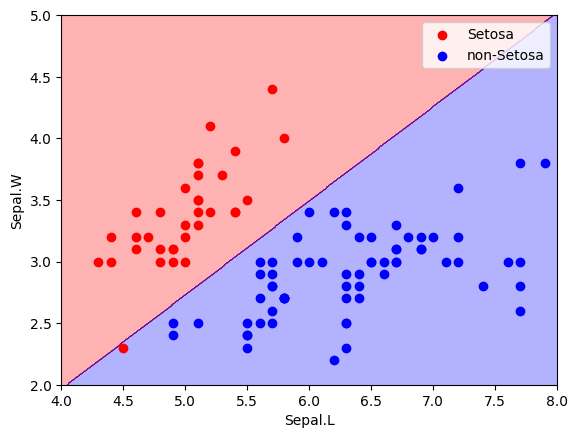

In [56]:
svm = SVM()
for i in range(3):
    svm.fit(X_train.values, y_train.values, line=True)

accuracy_test = cal_accuracy(y_test.values,X_test.values, svm, line=True)
accuracy_train = cal_accuracy(y_train.values,X_train.values, svm, line=True)

x_line = np.linspace(4,8,500)
y_line = np.linspace(2,5,500)
z_line = []
for x in x_line:
    for y in y_line:
        z_line.append(svm.predict(np.array([[x,y]]), line=True))

z_line = np.array(z_line)
z_line = z_line.reshape((500,500))

plt.contourf(x_line, y_line, z_line,alpha=0.3, colors=['red','blue'])
plt.scatter(X_train[y_train == 1]['Sepal.L'], X_train[y_train == 1]['Sepal.W'], color='red', label='Setosa')
plt.scatter(X_train[y_train == -1]['Sepal.L'], X_train[y_train == -1]['Sepal.W'], color='blue', label='non-Setosa')
plt.ylabel('Sepal.W')
plt.xlabel('Sepal.L')
plt.legend()
accuracy_test, accuracy_train, svm.weights, svm.bias

### квадратичное

(0.98,
 1.0,
 array([ 4.853 ,  3.257 ,  1.5993, -3.1291,  3.1399]),
 1.9300000000000015)

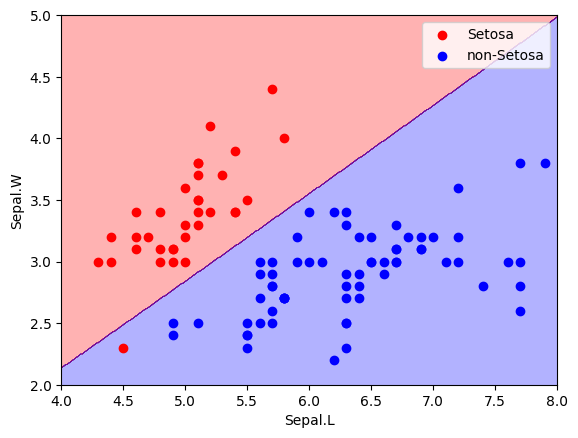

In [57]:
svm = SVM()
for i in range(3):
    svm.fit(X_train.values, y_train.values, line=False)

accuracy_test = cal_accuracy(y_test.values,X_test.values, svm, line=False)
accuracy_train = cal_accuracy(y_train.values,X_train.values, svm, line=False)

x_line = np.linspace(4,8,500)
y_line = np.linspace(2,5,500)
z_line = []
for x in x_line:
    for y in y_line:
        z_line.append(svm.predict(np.array([[x,y]]), line=False))

z_line = np.array(z_line)
z_line = z_line.reshape((500,500))

plt.contourf(x_line, y_line, z_line,alpha=0.3, colors=['red','blue'])
plt.scatter(X_train[y_train == 1]['Sepal.L'], X_train[y_train == 1]['Sepal.W'], color='red', label='Setosa')
plt.scatter(X_train[y_train == -1]['Sepal.L'], X_train[y_train == -1]['Sepal.W'], color='blue', label='non-Setosa')
plt.ylabel('Sepal.W')
plt.xlabel('Sepal.L')
plt.legend()

accuracy_test, accuracy_train, svm.weights, svm.bias

# Доп тест

In [58]:
df_dop = pd.read_csv('dop.csv')
df_dop = df_dop.drop('Petal.L', axis=1)
df_dop = df_dop.drop('Petal.W', axis=1)
df_dop

,Sepal.L,Sepal.W
0,6.0,2.9
1,5.2,3.0
2,5.7,2.8
3,5.4,3.4
4,6.7,3.3
5,5.9,3.1
6,5.9,2.9
7,6.5,3.0
8,5.5,2.9
9,6.2,2.9


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


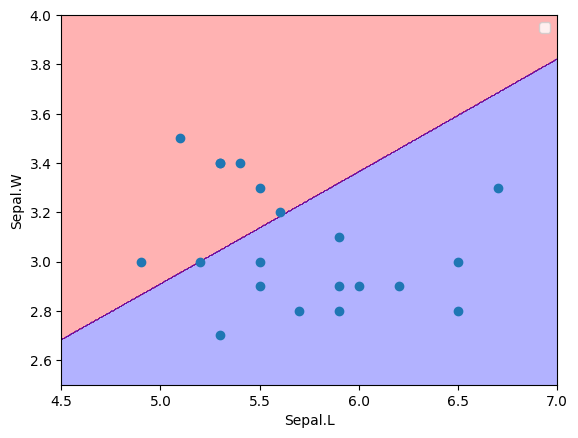

In [60]:
x_line = np.linspace(4.5,7,500)
y_line = np.linspace(2.5,4,500)
z_line = []
for x in x_line:
    for y in y_line:
        z_line.append(svm.predict(np.array([[x,y]]), line=False))

z_line = np.array(z_line)
z_line = z_line.reshape((500,500))

plt.contourf(x_line, y_line, z_line,alpha=0.3, colors=['red','blue'])
plt.scatter(df_dop['Sepal.L'], df_dop['Sepal.W'])
plt.ylabel('Sepal.W')
plt.xlabel('Sepal.L')
plt.legend()

In [64]:
result = svm.predict(df_dop.values, line=False)
for i in range(len(result)):
    if (result[i] == 1):
        print(df_dop.values[i],'Setosa')
    else:
        print(df_dop.values[i],'non-Setosa')

[6.  2.9] non-Setosa
[5.2 3. ] Setosa
[5.7 2.8] non-Setosa
[5.4 3.4] Setosa
[6.7 3.3] non-Setosa
[5.9 3.1] non-Setosa
[5.9 2.9] non-Setosa
[6.5 3. ] non-Setosa
[5.5 2.9] non-Setosa
[6.2 2.9] non-Setosa
[5.5 3. ] non-Setosa
[4.9 3. ] Setosa
[5.5 3.3] Setosa
[5.1 3.5] Setosa
[5.3 3.4] Setosa
[5.9 2.8] non-Setosa
[5.3 3.4] Setosa
[6.5 2.8] non-Setosa
[5.6 3.2] Setosa
[5.3 2.7] non-Setosa
